# 멀티모달 AI Agent

## 1.환경준비

### (1) 라이브러리 설치

In [ ]:
!pip -q install langgraph pillow -q

### (2) 라이브러리 로딩

In [2]:
import os, base64, io, requests, json
from typing import Annotated, TypedDict, List
from PIL import Image

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool

from openai import OpenAI

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### (3) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (4) OpenAI API Key 등록
* 환경변수로 key 등록

In [3]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '../'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'API_KEY.env')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [4]:
print(os.environ['OPENAI_API_KEY'][:3])

sk-


## 2.Agent 구성해보기

* 다음과 같은 그래프로 Agent를 구성해 봅시다.

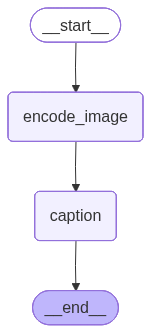

### (1) State 정의

In [5]:
# OpenAI client 선언
client = OpenAI()

In [6]:
class State(TypedDict):
    prompt: str
    image_path: str
    image_b64: str
    caption: str

### (2) 노드 함수

* 이미지 변환 함수

In [7]:
def b64_encoding(path: str) -> str:
    with open(path, "rb") as f:
        b = f.read()
    b64 = base64.b64encode(b).decode()  # base64로 인코딩한 뒤, bytes → str로 디코딩해 문자열을 얻음
    # MIME은 간단히 png/jpg만 케이스 분기
    ext = path.lower().split(".")[-1]   # 파일 확장자를 소문자로 뽑아냄
    mime = "image/png" if ext=="png" else "image/jpeg"
    return f"data:{mime};base64,{b64}"  # Data URI 형식으로 문자열을 만들어 반환

* 노드 구현

In [8]:
# 노드1: base64 인코딩
def encode_image(state: State) -> State:
    state["image_b64"] = b64_encoding(state["image_path"])
    return state

# 노드2: gpt-4o-mini 캡셔닝
def caption_with_gpt4o(state: State) -> State:
    messages = [{"role": "system", "content": "너는 이미지 캡션을 만드는 전문가야."},
                {"role": "user",
                 "content": [{"type": "text", "text": state["prompt"]},
                             {"type": "image_url", "image_url": {"url": state["image_b64"]}}
                            ]}
                ]

    model = client.chat.completions.create(
        model = "gpt-4o-mini",
        messages = messages,
        temperature = 0.3,
        max_tokens = 60,
    )

    state["caption"] = model.choices[0].message.content
    return state

### (3) 그래프 구성

In [9]:
# 그래프 구성
graph = StateGraph(State)
graph.add_node("encode_image", encode_image)
graph.add_node("caption", caption_with_gpt4o)

graph.add_edge(START, "encode_image")
graph.add_edge("encode_image", "caption")
graph.add_edge("caption", END)

basic_app = graph.compile()

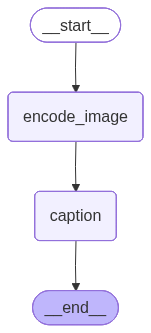

In [10]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(basic_app.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) 실행

* 파일 업로드

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 image_sonny.jpg 선택

In [12]:
state0 = {"prompt": "이미지를 한국어 한 문장으로만 출력해.",
          "image_path": "./data/image_sonny.jpg"}
final_state = basic_app.invoke(state0)

{'prompt': '이미지를 한국어 한 문장으로만 출력해.',
 'image_path': './data/image_sonny.jpg',
 'image_b64': '',
 'caption': '축구 경기에서 선수가 공을 드리블하고 있다.'}
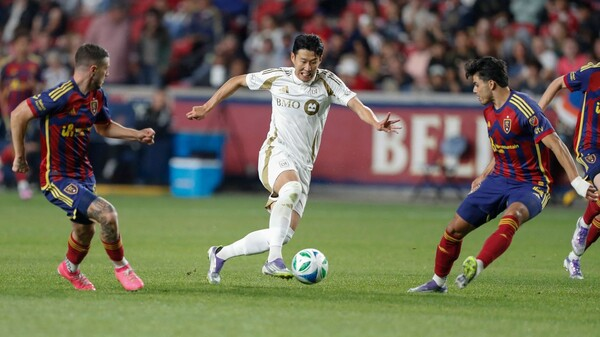

In [13]:
final_state


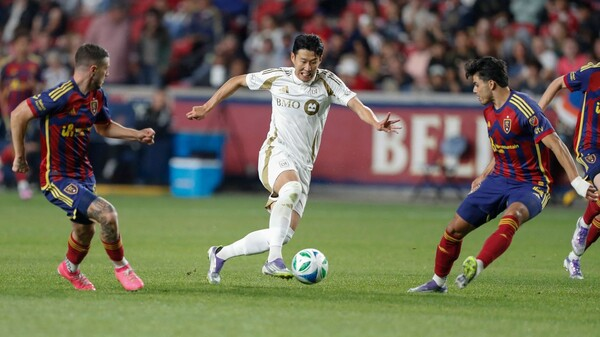

In [14]:
from IPython.display import display, HTML

image_src = final_state.get("image_b64")
cap = final_state.get("caption")

display(HTML(f"""
<figure style="text-align:left">
  <img src="{image_src}" style="max-width:560px;height:auto;" />
  <figcaption style="margin-top:8px;font-size:16px">{cap}</figcaption>
</figure>
"""))

## 3.실습
* 개요 : 그래프 이미지를 입력받아 음성으로 설명하는 Agent를 만들어 봅시다.
* Agent 구성
    * 그래프 이미지와 텍스트(지침, 그래프에 대한 최소 설명 등)를 입력으로 받아
    * 그래프를 분석하여 key point를 도출하고, 비즈니스 관점 해석
    * 분석 내용을 바탕으로 설명문 작성
    * 설명문을 음성으로 변환(TTS로 mp3 출력)

* 다음과 같은 그래프로 Agent를 구성해 봅시다.

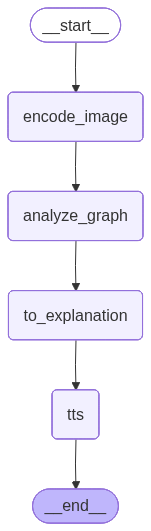

In [15]:
from typing import TypedDict, Optional, List, Annotated, Dict, Any
from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

import base64, json, io, os
from IPython.display import display, Audio, Image as DispImage, HTML
from PIL import Image

### (1) State 정의
* State에 담을 만한 내용을 적절하게 구성합니다.

In [16]:
# OpenAI client 선언
client = OpenAI()

In [17]:
class State(TypedDict):
    messages: List[dict]                 # OpenAI 스타일 메시지 로그
    prompt: str                # 사용자 프롬프트(분석 스타일 지시)
    image_path: str
    image_b64: str
    analysis: str
    explanation: str           # 최종 설명문(음성 합성용)
    audio_path: str          # 생성된 오디오 파일 경로

### (2) 노드 함수
* 이미지 변환 함수는 제공합니다.

In [ ]:
def b64_encoding(path: str) -> str:
    with open(path, "rb") as f:
        b = f.read()
    b64 = base64.b64encode(b).decode()  # base64로 인코딩한 뒤, bytes → str로 디코딩해 문자열을 얻음
    # MIME은 간단히 png/jpg만 케이스 분기
    ext = path.lower().split(".")[-1]   # 파일 확장자를 소문자로 뽑아냄
    mime = "image/png" if ext=="png" else "image/jpeg"
    return f"data:{mime};base64,{b64}"  # Data URI 형식으로 문자열을 만들어 반환

* 필요 노드 : 이미지 인코딩, 차트 분석, 설명문으로 정리, 음성변환

In [21]:
# base64 인코딩
def encode_image(state: State) -> State:
    """image_path가 있으면 image_b64에 data-uri 형태로 저장"""
    path = state.get("image_path", "")
    if not path or not os.path.exists(path):
        raise FileNotFoundError(f"image_path가 없거나 존재하지 않습니다: {path}")
    state["image_b64"] = b64_encoding(path)
    # 간단히 messages에 추가 (추후 모델 프롬프트 용)
    state.setdefault("messages", [])
    state["messages"].append({"role":"system", "content":"You are a concise graph analyst."})
    return state

# 그래프 분석 (gpt-4o-mini 멀티모달)
def analyze_graph(state: State) -> State:
    """멀티모달 모델에 그래프와 분석 지시를 보내 'analysis' 텍스트를 받음"""
    image_uri = state["image_b64"]
    # 구조화된 JSON으로 결과를 달라고 요청 (후처리에 유리)
    prompt = f"""
	Image: ![graph]({image_uri})

	You are a data analyst specialized in business insights. Analyze the graph image above and return a JSON object with the following keys:
	- axes: {{ "x": "label or unknown", "y": "label or unknown", "units": "if any" }}
	- key_points: [list of short bullet points describing main peaks/troughs/trends (each <= 120 chars)]
	- trends: short summary sentence about overall trend (<= 120 chars)
	- anomalies: [list of anomalies or irregularities, if none -> empty list]
	- suggested_metrics: [list of numeric metrics to extract or compute if raw data available]
	- business_implications: [short list of 2-4 actionable business insights]

	Please only output valid JSON (no extra commentary).
	"""
    # 호출 (model 이름은 환경에 맞춰 변경 가능)
    try:
        resp = client.responses.create(
            model="gpt-4o-mini",
            input=prompt,
            max_output_tokens=800
        )
        # SDK 버전 따라 결과 경로가 다를 수 있어 안전하게 추출
        if hasattr(resp, "output_text") and resp.output_text:
            out_text = resp.output_text
        else:
            # 일반적으로 resp.output is list of content items
            out_text = ""
            for item in getattr(resp, "output", []):
                for c in item.get("content", []):
                    out_text += c.get("text", "")
        # JSON 파싱 시도 (모델이 JSON을 반환했다고 가정)
        try:
            parsed = json.loads(out_text)
            state["analysis"] = json.dumps(parsed, ensure_ascii=False, indent=2)
        except Exception:
            # 실패하면 원문 저장
            state["analysis"] = out_text
    except Exception as e:
        state["analysis"] = f"ERROR during analysis: {e}"
    return state

# 설명문 생성
def to_explanation(state: State) -> State:
    """analysis 결과를 바탕으로 음성용 자연어 설명문(한국어, 40~60초 분량 권장) 생성"""
    analysis = state.get("analysis", "")
    prompt =f"""
	아래는 그래프 분석 결과(혹은 모델 출력)입니다. 이 내용을 바탕으로 한국어 음성 안내문(약 40~60초 분량, 자연스럽고 청취자가 이해하기 쉬운 문장) 하나를 작성하세요.
	제약: 문장은 짧고 명확하게, 총 길이는 약 3~7문장. 청중은 비즈니스 의사결정권자(비전문가)입니다.
	출력: 설명문(텍스트)만 출력하세요. 추가 설명 금지.

	--- 분석 결과 시작 ---
	{analysis}
	--- 분석 결과 끝 ---
	"""
    try:
        resp = client.responses.create(
            model="gpt-4o-mini",
            input=prompt,
            max_output_tokens=300
        )
        # 응답 텍스트 추출
        if hasattr(resp, "output_text") and resp.output_text:
            out_text = resp.output_text
        else:
            out_text = ""
            for item in getattr(resp, "output", []):
                for c in item.get("content", []):
                    out_text += c.get("text", "")
        state["explanation"] = out_text.strip()
    except Exception as e:
        state["explanation"] = f"ERROR during explanation generation: {e}"
    return state

# 음성 합성(gpt-4o-mini-tts)
def tts_with_gpt4o(state: State) -> State:
    """gpt-4o-mini-tts를 사용해 state['explanation']을 mp3로 저장"""
    text = state.get("explanation", "")
    if not text:
        raise ValueError("explanation이 비어있습니다.")
    out_path = state.get("audio_path", "graph_explanation.mp3")
    try:
        # SDK 함수 이름/반환 포맷은 버전에 따라 다름 -> 아래는 대표적인 사용 예시
        resp = client.audio.speech.create(
            model="gpt-4o-mini-tts",
            voice="alloy",     # SDK/모델에 따라 지원 voice가 다를 수 있음
            input=text
        )
        # 저장: resp의 속성 이름 차이를 대비하여 유연하게 처리
        audio_bytes = None
        if hasattr(resp, "audio"):
            audio_bytes = resp.audio
        elif hasattr(resp, "read"):
            audio_bytes = resp.read()
        elif isinstance(resp, (bytes, bytearray)):
            audio_bytes = resp
        else:
            # 혹시 JSON형 응답 안에 base64가 들어있다면 추출 (fallback)
            try:
                # 예: resp.dict().get("audio")
                d = resp.__dict__
                for v in d.values():
                    if isinstance(v, str) and v.startswith("data:audio"):
                        # data:audio/mpeg;base64,...
                        b64 = v.split(",")[1]
                        audio_bytes = base64.b64decode(b64)
                        break
            except Exception:
                pass

        if audio_bytes is None:
            raise RuntimeError("오디오 바이트를 추출하지 못했습니다. SDK 버전을 확인하세요.")
        with open(out_path, "wb") as f:
            f.write(audio_bytes)
        state["audio_path"] = out_path
    except Exception as e:
        state["audio_path"] = f"ERROR during tts: {e}"
    return state


### (3) 그래프 구성

In [23]:
# 그래프 구성
graph = StateGraph(State)

# 노드 추가
graph.add_node("encode_image", encode_image)
graph.add_node("analyze_graph", analyze_graph)
graph.add_node("to_explanation", to_explanation)
graph.add_node("tts_with_gpt4o", tts_with_gpt4o)

# 엣지 연결
graph.add_edge(START, "encode_image")
graph.add_edge("encode_image", "analyze_graph")
graph.add_edge("analyze_graph", "to_explanation")
graph.add_edge("to_explanation", "tts_with_gpt4o")
graph.add_edge("tts_with_gpt4o", END)

# 그래프 컴파일
basic_app = graph.compile()

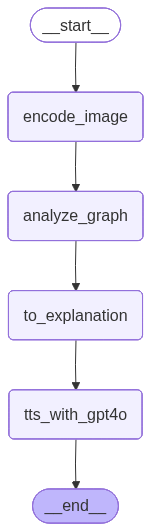

In [24]:
basic_app

### (4) 실행

* 파일 업로드

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 scatterplot1.jpg 선택

In [25]:
state0 = {"prompt": "# 그래프 기본 설명 : price와 sales의 관계",
          "image_path": "./data/scatterplot1.png" }

final_state = basic_app.invoke(state0)

{'messages': [{'role': 'system',
   'content': 'You are a concise graph analyst.'}],
 'prompt': '# 그래프 기본 설명 : price와 sales의 관계',
 'image_path': './data/scatterplot1.png',
 'image_b64': '',
 'analysis': '```json\n{\n  "axes": {\n    "x": "Time or Category Unknown",\n    "y": "Value or Metric Unknown",\n    "units": "Unknown"\n  },\n  "key_points": [\n    "Significant peak observed around the mid-point of the graph.",\n    "A noticeable trough follows shortly after the peak.",\n    "Values seem to trend upwards towards the end of the graph.",\n    "A sharp drop occurs just before the final rise."\n  ],\n  "trends": "Overall, the trend shows an upward movement after initial fluctuations.",\n  "anomalies": [],\n  "suggested_metrics": [\n    "Peak values and their timestamps",\n    "Trough values and their timestamps",\n    "Rate of change between significant points",\n    "Overall average value over time span"\n  ],\n  "business_implications": [\n    "Evaluate factors contributing to peak
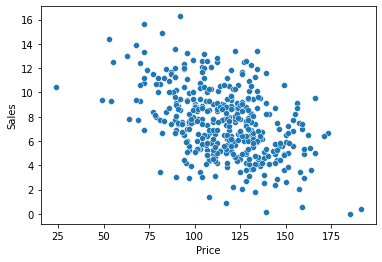

In [26]:
final_state


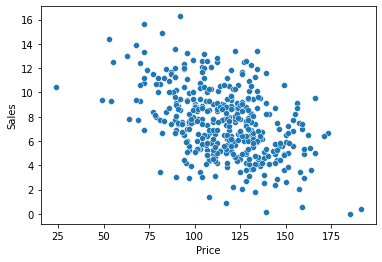


설명문:

```json
{
  "axes": {
    "x": "Time or Category Unknown",
    "y": "Value or Metric Unknown",
    "units": "Unknown"
  },
  "key_points": [
    "Significant peak observed around the mid-point of the graph.",
    "A noticeable trough follows shortly after the peak.",
    "Values seem to trend upwards towards the end of the graph.",
    "A sharp drop occurs just before the final rise."
  ],
  "trends": "Overall, the trend shows an upward movement after initial fluctuations.",
  "anomalies": [],
  "suggested_metrics": [
    "Peak values and their timestamps",
    "Trough values and their timestamps",
    "Rate of change between significant points",
    "Overall average value over time span"
  ],
  "business_implications": [
    "Evaluate factors contributing to peak performance.",
    "Investigate causes of the significant drop.",
    "Consider strategies to sustain growth trend.",
    "Identify opportunities during low performance periods."
  ]
}
```


In [27]:
image_src = final_state.get("image_b64")
display(HTML(f"""
<figure style="text-align:left">
  <img src="{image_src}" style="max-width:560px;height:auto;" />
</figure>
"""))

print("\n설명문:\n")
print(final_state.get("analysis","(설명 없음)"))

if final_state.get("audio_path") and os.path.exists(final_state["audio_path"]):
    display(Audio(filename=final_state["audio_path"], autoplay=False))
else:
    print("\n오디오 파일 생성 실패 또는 경로 없음:", final_state.get("audio_path"))